In [26]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
PROJECT_ROOT = Path('/Users/apch/Pycharmproekti/nn_real_estate')

# ─── 1. ЗАГРУЗКА МОДЕЛИ И ДАННЫХ ─────────────────────────────
bundle = joblib.load(PROJECT_ROOT / 'models' / 'catboost_model.pkl')
model        = bundle['model']
target_map   = bundle['target_map']
global_mean  = bundle['global_mean_m2']
features     = bundle['features']

X = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'X_shap.csv')

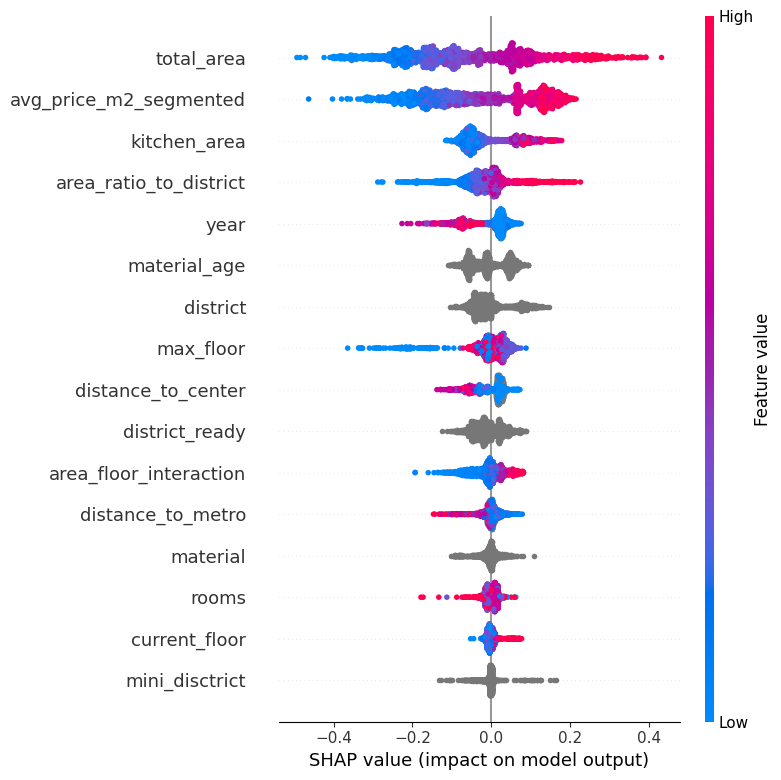

SHAP values shape: (2000, 16)
Всего 4 основых признака, которые являются драйверами основной цены:
Площадь:На Summary Plot мы видим самый длинный хвост именно здесь. Это подтверждает, что в недвижимости цена в первую очередь — это функция от объема «бетона». Любое отклонение в метраже дает самый сильный сдвиг в рублях.
Отношение площади квартиры к типичной площади квартиры в ее районе: Если в районе средняя площадь — 40 m^2 (хрущевки), а твоя квартира — 90 m^2, то этот признак подсвечивает модели, что объект аномален для данной локации и является престижем
Площадь кухни: В старом фонде кухни 5–6 m^2, в «комфорт-плюсе» — от 12 m^2. Большая кухня — это прокси-переменная для «европланировок»
Средняя цена за квадртаный метр площади, высчитанной по каждому сегменту(определенному с помощью максимальной этажности) в каждом районе: Результат: Этот признак сужает поиск для CatBoost. Вместо того чтобы искать цену по всему городу, модель сразу попадает в нужный «ценовой коридор»


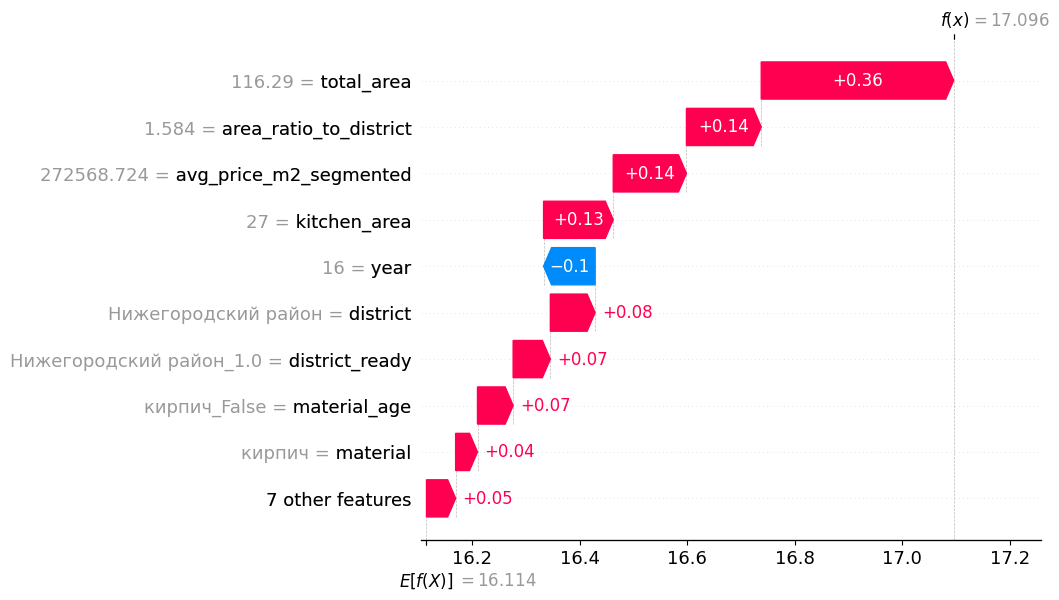

Waterfall plot — самая дорогая квартира в сэмпле
Нижегородский район, 116.29 м², кирпич
Базовое предсказание: exp(16.114) = ~9.97 млн ₽ (средняя по датасету)
Итоговое: exp(17.096) = ~26.6 млн ₽
Что сделало квартиру дорогой:
+0.36 total_area=116.29     — большая площадь, главный драйвер
+0.14 area_ratio=1.584      — на 58% больше средней в районе → премиум
+0.14 avg_price_m2=272 568  — дорогой сегмент рынка в Нижегородском районе
+0.13 kitchen_area=27       — большая кухня → европланировка
+0.08 district=Нижегородский — исторический центр, элитный сегмент
-0.10 year=16               — здание среднего возраста, небольшой дисконт


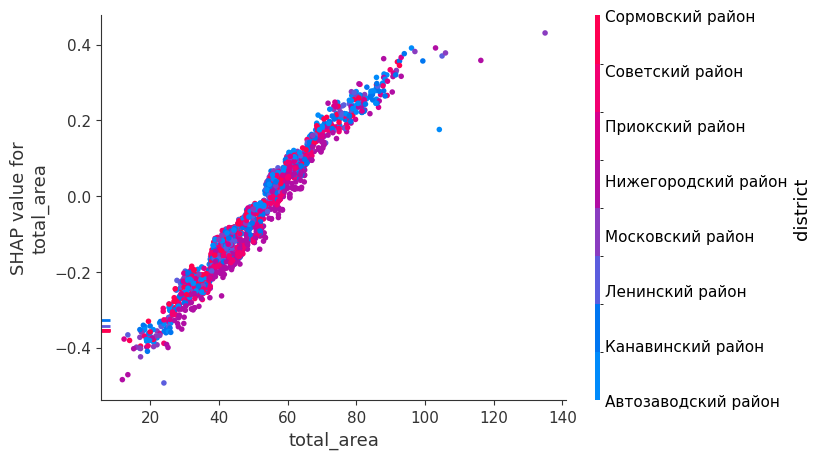

Dependence plot: total_area → SHAP value, цвет = район

Зависимость почти идеально линейная —
каждый дополнительный м² даёт примерно одинаковый прирост к цене.

Ключевые наблюдения:

1. Кластер слева (total_area < 20м²): все точки уходят в -0.35...-0.4
   независимо от района — очень маленькие квартиры модель
   оценивает одинаково низко вне зависимости от локации.

2. Цвет точек перемешан равномерно по всей линии —
   район НЕ влияет на то как площадь транслируется в цену.
   district добавляет фиксированный 'лифт' к цене,
   но не усиливает эффект площади.

3. Два выброса вверху справа (>100м², SHAP ~0.4) —
   аномально дорогие для своего района,
   скорее всего элитные новостройки в нетипичных локациях.

4. Разброс точек растёт с площадью —
   для маленьких квартир предсказание стабильное,
   для больших (>80м²) больше неопределённости.
   Крупные квартиры разнообразнее по классу жилья.


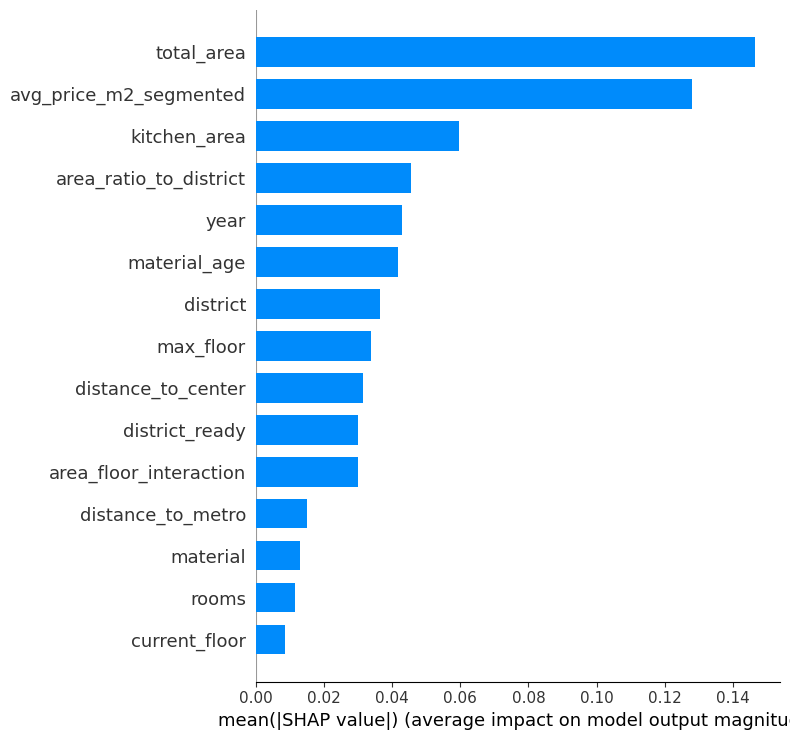

Bar plot — средняя важность признаков (mean |SHAP value|)

ТОП-2 с отрывом:
total_area (~0.148)        — абсолютный лидер, в 2х важнее третьего признака
avg_price_m2_segmented (~0.130) — локальный ценовой ориентир почти догоняет площадь

Средний пояс (0.04-0.06) — примерно равнозначны:
kitchen_area, area_ratio_to_district, year, material_age, district, max_floor
Это физические характеристики квартиры + возраст + локация.
Ни один не доминирует — модель использует их совместно.

Аутсайдеры (< 0.02):
distance_to_metro, material, rooms, current_floor
Слабый вклад distance_to_metro объясняется 52% пропусков в геоданных —
признак мог бы быть сильнее при полном геокодинге.

Главный вывод:
Цена квартиры в Нижнем Новгороде определяется в первую очередь
СКОЛЬКО бетона (total_area) и ГДЕ на рынке (avg_price_m2_segmented).
Всё остальное — уточняющие факторы второго порядка.


In [44]:
# ─-─ 3. SHAP EXPLAINER ───────────────────────────────────────
# CatBoost имеет встроенную поддержку SHAP — быстро и точно
explainer = shap.TreeExplainer(model)

# Считаем SHAP-значения на тестовой выборке (300 объектов достаточно)
# Больше объектов = дольше считается
sample = X.sample(2000, random_state=41).reset_index(drop=True)
shap_values = explainer.shap_values(sample)


# ─── 4. SUMMARY PLOT — глобальная важность ───────────────────
plt.style.use('default')  # до построения SHAP

plt.figure()

shap.summary_plot(shap_values, sample, feature_names=features)
print(f"SHAP values shape: {shap_values.shape}")
# (300, n_features) — для каждого объекта и каждого признака
print("Всего 4 основых признака, которые являются драйверами основной цены:")
print("Площадь:На Summary Plot мы видим самый длинный хвост именно здесь. Это подтверждает, что в недвижимости цена в первую очередь — это функция от объема «бетона». Любое отклонение в метраже дает самый сильный сдвиг в рублях.")
print("Отношение площади квартиры к типичной площади квартиры в ее районе: Если в районе средняя площадь — 40 m^2 (хрущевки), а твоя квартира — 90 m^2, то этот признак подсвечивает модели, что объект аномален для данной локации и является престижем")
print("Площадь кухни: В старом фонде кухни 5–6 m^2, в «комфорт-плюсе» — от 12 m^2. Большая кухня — это прокси-переменная для «европланировок»")
print("Средняя цена за квадртаный метр площади, высчитанной по каждому сегменту(определенному с помощью максимальной этажности) в каждом районе: Результат: Этот признак сужает поиск для CatBoost. Вместо того чтобы искать цену по всему городу, модель сразу попадает в нужный «ценовой коридор»")
# Читать так:
# - Ось X: SHAP-значение (вклад в предсказание в log-ценах)
# - Цвет: красный = высокое значение признака, синий = низкое
# - Пример: total_area красные точки справа → большая площадь → выше цена

# ─── 5. WATERFALL PLOT — объяснение одной квартиры ───────────
# Берём квартиру из датасета — например самую дорогую в тесте
idx = sample.index[np.argmax(
    np.exp(model.predict(sample))
)]


shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[sample.index.get_loc(idx)],
        base_values=explainer.expected_value,
        data=sample.loc[idx],
        feature_names=features
    )
)
print("Waterfall plot — самая дорогая квартира в сэмпле")
print("Нижегородский район, 116.29 м², кирпич")
print(f"Базовое предсказание: exp(16.114) = ~9.97 млн ₽ (средняя по датасету)")
print(f"Итоговое: exp(17.096) = ~{np.exp(17.096)/1e6:.1f} млн ₽")
print("Что сделало квартиру дорогой:")
print("+0.36 total_area=116.29     — большая площадь, главный драйвер")
print("+0.14 area_ratio=1.584      — на 58% больше средней в районе → премиум")
print("+0.14 avg_price_m2=272 568  — дорогой сегмент рынка в Нижегородском районе")
print("+0.13 kitchen_area=27       — большая кухня → европланировка")
print("+0.08 district=Нижегородский — исторический центр, элитный сегмент")
print("-0.10 year=16               — здание среднего возраста, небольшой дисконт")
# ─── 6. DEPENDENCE PLOT — влияние total_area ─────────────────

shap.dependence_plot(
    'total_area',
    shap_values,
    sample,
    feature_names=features,
    interaction_index='district',  # цвет = район
    show=True
)
# Покажет: как вклад площади в цену меняется при разных значениях площади
# и как это зависит от района

# ─── 7. BAR PLOT — средняя важность признаков ────────────────
plt.figure()
print("Dependence plot: total_area → SHAP value, цвет = район")
print()
print("Зависимость почти идеально линейная —")
print("каждый дополнительный м² даёт примерно одинаковый прирост к цене.")
print()
print("Ключевые наблюдения:")
print()
print("1. Кластер слева (total_area < 20м²): все точки уходят в -0.35...-0.4")
print("   независимо от района — очень маленькие квартиры модель")
print("   оценивает одинаково низко вне зависимости от локации.")
print()
print("2. Цвет точек перемешан равномерно по всей линии —")
print("   район НЕ влияет на то как площадь транслируется в цену.")
print("   district добавляет фиксированный 'лифт' к цене,")
print("   но не усиливает эффект площади.")
print()
print("3. Два выброса вверху справа (>100м², SHAP ~0.4) —")
print("   аномально дорогие для своего района,")
print("   скорее всего элитные новостройки в нетипичных локациях.")
print()
print("4. Разброс точек растёт с площадью —")
print("   для маленьких квартир предсказание стабильное,")
print("   для больших (>80м²) больше неопределённости.")
print("   Крупные квартиры разнообразнее по классу жилья.")
shap.summary_plot(
    shap_values,
    sample,
    feature_names=features,
    plot_type='bar',
    max_display=15,
    show=True
)
print("Bar plot — средняя важность признаков (mean |SHAP value|)")
print()
print("ТОП-2 с отрывом:")
print("total_area (~0.148)        — абсолютный лидер, в 2х важнее третьего признака")
print("avg_price_m2_segmented (~0.130) — локальный ценовой ориентир почти догоняет площадь")
print()
print("Средний пояс (0.04-0.06) — примерно равнозначны:")
print("kitchen_area, area_ratio_to_district, year, material_age, district, max_floor")
print("Это физические характеристики квартиры + возраст + локация.")
print("Ни один не доминирует — модель использует их совместно.")
print()
print("Аутсайдеры (< 0.02):")
print("distance_to_metro, material, rooms, current_floor")
print("Слабый вклад distance_to_metro объясняется 52% пропусков в геоданных —")
print("признак мог бы быть сильнее при полном геокодинге.")
print()
print("Главный вывод:")
print("Цена квартиры в Нижнем Новгороде определяется в первую очередь")
print("СКОЛЬКО бетона (total_area) и ГДЕ на рынке (avg_price_m2_segmented).")
print("Всё остальное — уточняющие факторы второго порядка.")